# langchin_google_genai
- gemini 활용 시 사용하는 langchain 라이브러리
- ChatGoogleGenerativeAI 라이브러리의 model에 사용하고자 하는 모델 명을 기입, api_key의 경우 기입하지 않아도 GEMINI_API_KEY 환경변수의 값을 가져와 사용

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", api_key=os.getenv("GEMINI_API_KEY"))

# API를 통한 검색 방법
- BaseModel 활용 : 필드를 넣어 답변 스키마를 지정 
    - TypedDict는 BaseModel보다 낮은 검증
    - Field는 BaseModel의 필드에 description을 추가하는데 Langchain에서는 description을 통해 '어떤 답변을 넣어야 하는지' 알려주는 안내문 역할을 한다.
- invoke()를 통해 답변을 받는다. 

In [2]:
from pydantic import BaseModel, Field
class SearchQuery(BaseModel) : 
    search_query: str = Field(None, description = "검색어")
    justification : str = Field(None, description= "why this query is relevant to the user question")
    
structured_llm = llm.with_structured_output(SearchQuery) 

output = structured_llm.invoke("What is the capital of South Korea and why do you think this is the answer?")
print(output.search_query)
print(output.justification)

capital of South Korea
The user is asking for a factual geographical identifier, and searching for the capital of South Korea will provide the verified administrative center of the country.


# tool calling
- bind_tools를 통해 여러 tool들을 등록시킬 수 있는데 기존과 다른점은 invoke를 통해 구성된 답을 받는것이 아닌 어떤 메서드를 활용해야 할 지 return 받는다. (인자 생성 포함)
- tool calling과 상관 없는 질문 시 일반 답변이 나온다. ("안녕?" > "안녕하세요?")


In [ ]:
def multiply(a: int, b: int) -> int : 
    """ Multiplies two numbers together."""
    return a * b

llm_with_tools = llm.bind_tools([multiply])

msg = llm_with_tools.invoke("What is 2 times 3?")

print(msg.tool_calls)
# msg.text의 경우 tool_calls를 호출했기 때문에 빈값을 반환한다.

[{'name': 'multiply', 'args': {'b': 3, 'a': 2}, 'id': '58f7405b-042a-44c6-99a0-c67e9cacbf93', 'type': 'tool_call'}]


In [ ]:
# 상관없는 질문을 했을 때
def multiply(a: int, b: int) -> int : 
    """ Multiplies two numbers together."""
    return a * b

llm_with_tools = llm.bind_tools([multiply])

msg = llm_with_tools.invoke("안녕?")

msg

AIMessage(content=[{'type': 'text', 'text': '안녕하세요! 만나서 반가워요. 오늘 어떤 도움을 드릴까요?', 'extras': {'signature': 'EjQKMgEMOdbHT2qyUPTkalrW9TRU2lZ7cBT7s6QulPZGot7FtLGnr4H2+lBhlFJZkDsrOp5p'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e53c3-a324-7fc0-9a92-25b93fecad6e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 58, 'output_tokens': 16, 'total_tokens': 74, 'input_token_details': {'cache_read': 0}})

# condition(조건)에 따라 분기되는 workflow
- anthropic api를 활용하는 영상에선 응답값을 msg.content를 통해 받아왔는데 gemini의 경우 그렇게 받아오면 예상한 타입과 다르게 받아오기 때문에 안된다. (리스트로 가져옴, 멀티모델이라 그런가 ) 쨋든 그래서 text로 가져와야함

In [44]:
from typing_extensions import TypedDict
# Graph State
class State(TypedDict) : 
    topic: str
    joke: str
    improve_joke: str
    final_joke: str

In [45]:
# Nodes
def generate_joke(state: State) -> str : 
    """ Generate a joke about the given topic. """
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {'joke': msg.text}


def improve_joke(state: State) -> str: 
    """ Second LLM call to improve the joke """
    msg = llm.invoke(f"Improve the following joke: {state['joke']}")
    return {'improve_joke': msg.text}   


def polish_joke(state: State) -> str : 
    """ Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surpring twist to this joke: {state['improve_joke']}")
    return {'final_joke': msg.text}

# Conditional edge function to check if the joke has a punchline
def check_punchline(state : State) -> bool : 
    """ Check if the joke has a punchline. """
    
    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"] : 
        return "Pass"
    return "Fail"
    

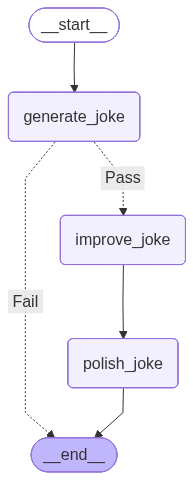

In [46]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Build Workflow
workflow = StateGraph(State) 

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke) 

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges("generate_joke", 
                               check_punchline,
                               {"Pass" : "improve_joke", "Fail" : END})
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

In [47]:
state = chain.invoke({"topic": "cats"})
print(state['joke'])
if "improve_joke" in state : 
    print(" The joke had a punchline, so it was improved. ")
    print(state['improve_joke'])
    
    print(" The improved joke was polished with a surprising twist. ")
    print(state['final_joke'])
else :  
    print("The joke did not have a punchline, so it was not improved.")


Why was the cat sitting on the computer?

He wanted to keep an eye on the mouse!
 The joke had a punchline, so it was improved. 
Here are a few ways to improve the joke, depending on the type of humor you want:

**1. The "Punny" Twist (Best for a classic delivery)**
> "Why was the cat sitting on the computer?
> 
> He wanted to **monitor** the mouse."

**2. The Relatable/Modern Version**
> "Why did the cat sit on the keyboard?
> 
> He heard it was the best place to find a **mouse**."

**3. The "Dad Joke" Expansion**
> "Why was the cat sitting on the computer?
> 
> He heard the mouse was running, and he didn't want to miss the **cursor**-y glance."

**4. The Short & Punchy Version**
> "Why was the cat staring at the computer screen?
> 
> He was waiting for the mouse to **click**."

**My personal favorite is the "monitor" version (Option 1)** because it creates a double meaning with the computer hardware!
 The improved joke was polished with a surprising twist. 
To add a surprising, dark,

# Orchestrator-Worker
오케스트레이터는 작업을 분배하고 분배된 sub-task를 sub-worker에게 위임한다.

In [48]:
from pydantic import BaseModel, Field
from typing import Annotated, List
import operator

# Schema for structured output to use in plannging
class Section(BaseModel) : 
    name: str = Field(description="Name for this section of the report")
    description: str = Field(description="Brief overview of the main topics and concepts to be covered in this section. ")

class Sections(BaseModel) : 
    sections: List[Section] = Field(description="Sections for the report")

# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

In [ ]:
# Graph state
class State(TypedDict) : 
    topic: str
    sections: List[Section]
    # 내가 알기론 Annotated는 타입에 메타데이터(설명)을 추가하는데 여기서는 operator.add를 메타데이터로 추가하였다.  
    # langchain에서 Annotated는 상태의 특정 필드가 어떻게 업데이트되어야 하는지를 나타내는데 사용된다. + 메서드를 개발하여 상태의 필드가 어떻게 업데이트되어야 하는지를 정의할 수 있다.
    # completed_sections는 여러 worker 결과가 누적되는 필드다.
    completed_sections: Annotated[
        list, operator.add
    ]
    final_report: str
    
# Worker state
class WorkerState(TypedDict) : 
    section : Section
    completed_sections: Annotated[list, operator.add]

NameError: name 'TypedDict' is not defined

In [ ]:
# SystemMessage 는 모델에게 주는 지침 
# HumanMessage 는 사용자의 질문/요청
from langchain_core.messages import SystemMessage, HumanMessage

# Send는 워크들을 동적으로 생성하여 실행시키는 객체
from langgraph.types import Send


def orchestrator(state: State) : 
    """Orchestrator that generates a plan for the report"""
    
    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report"),
            HumanMessage(content=f"Here is the section report topic: {state['topic']}")
        ]
    )
    
    return {"sections": report_sections.sections}

def llm_call(state: WorkerState) : 
    """Worker writes a section of the report"""
    section = llm.invoke(
        [
            SystemMessage(content = "Write a report section."),
            HumanMessage(
                content=f"Here is the section name : {state['section'].name} and description: {state['section'].description}"
            )
        ]
    )
    
    return {"completed_sections": [section.text]}

def synthesizer(state: State) : 
    """ Synthesizer full report from sections """
    
    # List of completed sections
    completed_sections = state["completed_sections"]
    
    completed_report_sections = "\n\n---\n\n".join(completed_sections) 
    
    return {"final_report" : completed_report_sections}

def assign_workers(state : State) :
    """ Assign a worker to each section in the plan"""
    
    return [Send("llm_call", {"section" : s}) for s in state["sections"]]

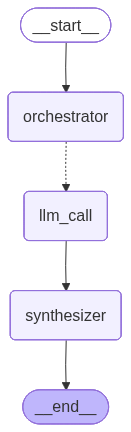

In [ ]:

orchestrator_worker_builder = StateGraph(State) 
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call) 
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)

orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)    

orchestrator_worker = orchestrator_worker_builder.compile()

display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))


In [52]:
state = orchestrator_worker.invoke({"topic": "The impact of climate change on global agriculture."})

In [53]:
state["sections"]

[Section(name='Introduction to Climate Change and Agriculture', description='Definition of key climate trends and an overview of how they interact with fundamental agricultural systems globally.'),
 Section(name='Direct Impacts on Crop Production', description='Analysis of how shifting temperatures, altered precipitation patterns, and extreme weather events affect crop yields and quality.'),
 Section(name='Water Scarcity and Soil Health', description='Examination of the relationship between changing climate conditions, irrigation requirements, desertification, and soil degradation.'),
 Section(name='Pests, Diseases, and Biodiversity Loss', description='Discussion on how warming climates influence the migration of agricultural pests and the prevalence of plant diseases, as well as the loss of vital pollinators.'),
 Section(name='Socio-Economic Consequences for Global Food Security', description='Assessment of how agricultural disruptions impact food prices, market stability, and the liv

In [54]:
from IPython.display import Markdown
Markdown(state["final_report"])

## 1. Introduction to Climate Change and Agriculture

The intersection of climate change and global agriculture represents one of the most significant systemic challenges of the 21st century. As the atmospheric concentration of greenhouse gases continues to rise, the resulting shifts in climatic norms are fundamentally altering the biological, chemical, and physical parameters upon which food production depends.

### Key Climate Trends
Current climate modeling highlights four primary trends that are reshaping the agricultural landscape:

*   **Rising Mean Temperatures:** Long-term increases in global average temperatures are accelerating phenological stages in crops, often shortening growing seasons and reducing yield potential. 
*   **Altered Precipitation Patterns:** Changes in the frequency, intensity, and duration of rainfall are creating a dichotomy of risks, characterized by prolonged droughts in arid and semi-arid regions and severe, episodic flooding in others.
*   **Increased Climate Variability:** Beyond linear trends, the heightened frequency of extreme weather events—such as heatwaves, late-spring frosts, and intense tropical storms—poses a persistent threat to harvest stability.
*   **Atmospheric Composition Changes:** Rising levels of carbon dioxide ($CO_2$) have a dual effect: while potentially stimulating photosynthesis (the "fertilization effect"), they can simultaneously degrade the nutritional density of staple crops and alter weed competitiveness.

### Interaction with Agricultural Systems
These climatic trends do not operate in isolation; they interact with agricultural systems through complex feedback loops. For instance, the stress induced by high temperatures can weaken crop resistance to pests and pathogens, which are themselves expanding into new latitudes due to warming winters. 

Globally, these interactions create profound vulnerabilities. In regions reliant on rain-fed agriculture, unpredictable precipitation threatens the livelihoods of smallholder farmers and jeopardizes regional food security. Simultaneously, in industrialized agricultural systems, the disruption of traditional seasonal cycles forces a reliance on resource-intensive adaptive measures—such as increased irrigation and synthetic inputs—which can, in turn, exacerbate the environmental pressures driving climate change. 

Understanding this nexus is essential for developing resilient production frameworks. This report will examine how the interplay between these climatic drivers and agricultural practices necessitates a transition toward climate-smart strategies, balancing the urgent need for high-yield productivity with the necessity of environmental stewardship.

---

### Direct Impacts on Crop Production

The stability of global food security is increasingly threatened by the direct physiological and environmental pressures exerted by a changing climate. As agricultural systems are intrinsically linked to specific climatic envelopes, the ongoing shifts in temperature, precipitation, and the frequency of extreme weather events are recalibrating the baseline for crop yields and nutritional quality.

#### Temperature-Induced Physiological Stress
Rising mean temperatures and the increasing frequency of heatwaves are accelerating phenological development in many staple crops, such as wheat, maize, and rice. While accelerated maturation may allow for earlier harvests, it simultaneously reduces the duration of the grain-filling period, leading to lighter kernels and lower overall yields. Furthermore, extreme heat during critical reproductive stages—such as anthesis (flowering)—can cause widespread pollen sterility, resulting in significant "yield gaps" even when water availability is adequate.

#### Altered Precipitation Patterns and Water Availability
Changes in the timing, intensity, and duration of precipitation are disrupting traditional planting and harvesting cycles. Erratic rainfall patterns pose a dual threat: 
*   **Drought Stress:** Prolonged dry spells during peak growth stages inhibit photosynthesis and nutrient uptake, causing stunted growth and premature senescence. 
*   **Excessive Moisture:** Conversely, intensified precipitation events increase the risk of waterlogging, which promotes root rot, nitrogen leaching, and physical damage to standing crops. These shifts exacerbate the vulnerability of rain-fed agricultural systems, which currently account for the majority of global food production.

#### Impacts on Crop Quality and Nutritional Profile
Beyond quantity, climate change is actively degrading the nutritional density of crops. Research indicates that elevated atmospheric carbon dioxide (CO2) concentrations—while potentially fertilizing for some species—often lead to a "dilution effect." This phenomenon results in significantly lower concentrations of essential minerals, such as iron and zinc, and reduced protein content in C3 crops like wheat and rice. Additionally, increased temperatures can disrupt the synthesis of secondary metabolites, potentially altering the sensory characteristics, shelf life, and marketability of fruits and vegetables.

#### Extreme Weather and Systemic Volatility
Extreme weather events, including flash floods, severe hailstorms, and prolonged frost, act as acute shocks to agricultural systems. Unlike gradual climate shifts, these events can cause catastrophic, localized yield losses in a matter of hours. The increasing stochasticity of these events complicates long-term agricultural planning and increases volatility in global commodity markets, forcing a transition toward more resilient crop varieties and adaptive management strategies, such as improved irrigation efficiency and diversified cropping systems.

---

## 3.4 Water Scarcity and Soil Health

The relationship between water scarcity and soil health forms a critical feedback loop that determines the long-term viability of agricultural systems. As climate change accelerates the frequency and intensity of droughts, the resulting shifts in moisture availability trigger a cascade of ecological degradations that undermine the biological, chemical, and physical integrity of the soil.

### 3.4.1 Climate-Induced Irrigation Stress
Rising global temperatures have intensified evapotranspiration rates, significantly increasing the water demand for crops. In regions facing chronic water scarcity, this demand is frequently met through the over-extraction of groundwater and heavy reliance on irrigation. While irrigation acts as a buffer against precipitation variability, improper management—such as the use of saline or brackish water in water-stressed areas—leads to the gradual accumulation of salts in the soil profile. This process, known as secondary salinization, reduces the osmotic potential of soil water, effectively inducing "physiological drought" even when moisture is present, thereby stunting plant growth and reducing organic matter accumulation.

### 3.4.2 Desertification and Soil Degradation
Water scarcity acts as a primary catalyst for desertification, particularly in arid and semi-arid regions. The reduction in soil moisture content diminishes the resilience of soil biota, leading to a decline in microbial activity and carbon sequestration capacity. As soil moisture levels drop, vegetation cover recedes, leaving the topsoil vulnerable to wind and water erosion. The removal of the nutrient-rich topsoil layer significantly lowers the soil’s water-holding capacity (WHC), creating a vicious cycle: as the soil loses its ability to retain water, it becomes more susceptible to drought, which in turn accelerates further land degradation.

### 3.4.3 Consequences for Soil Structure and Fertility
The physical health of the soil is fundamentally tied to its water content. Dry, degraded soils often undergo crusting and compaction, which hinders root penetration and reduces water infiltration rates. When intermittent precipitation events finally occur, these compacted surfaces promote rapid surface runoff rather than deep-soil percolation. This prevents the replenishment of local aquifers and exacerbates nutrient leaching. Furthermore, the reduction in soil moisture limits the chemical weathering of minerals, slowing the release of essential plant nutrients and leading to a long-term decline in soil fertility. 

In summary, the nexus between water scarcity and soil health is characterized by a reciprocal decline. Addressing this challenge requires integrated land and water management strategies, such as the adoption of water-efficient irrigation technologies, the enhancement of soil organic matter to improve moisture retention, and the implementation of climate-smart agricultural practices designed to stabilize soil structure against increasing environmental volatility.

---

### Pests, Diseases, and Biodiversity Loss

The shifting global climate is fundamentally altering the biological dynamics of agricultural ecosystems. As temperature thresholds rise and seasonal patterns become increasingly unpredictable, the geographical ranges and reproductive cycles of agricultural pests and plant pathogens are undergoing significant expansion, posing an escalating threat to global food security.

**Expansion of Pests and Pathogens**
Warming climates have removed traditional thermal barriers that once limited the distribution of numerous agricultural pests. Milder winters allow for higher survival rates of overwintering populations, while warmer, longer growing seasons facilitate an increase in the number of generations per year for many insects. Consequently, species such as the fall armyworm and various aphid vectors are migrating into higher latitudes and altitudes, colonizing regions previously protected by colder climates. 

Parallel to pest migration, the prevalence of plant diseases is intensifying. Many fungal, bacterial, and viral pathogens thrive under the heat and humidity associated with climate change. Furthermore, stressed crops—compromised by erratic precipitation and heatwaves—exhibit weakened immune responses, rendering them more susceptible to infections. This creates a volatile feedback loop where decreased crop resilience leads to increased reliance on chemical interventions, which in turn can degrade soil health and further diminish ecosystem stability.

**Impact on Vital Pollinators**
Beyond direct crop damage, climate change threatens the intricate biological relationships essential for agricultural productivity, most notably the role of pollinators. The synchronization between the blooming of flowering crops and the activity cycles of essential pollinators, such as bees, butterflies, and hoverflies, is increasingly disrupted. Known as "phenological mismatch," this divergence occurs when rising temperatures trigger early plant flowering before pollinators have emerged or migrated to the region.

The loss of biodiversity—driven by habitat fragmentation, chemical exposure, and climate stress—further diminishes the resilience of these pollinator populations. As vital biodiversity declines, the stability of pollination services is compromised, threatening the yields of nutrient-dense crops that rely on biotic pollination. The resulting loss of ecosystem services not only jeopardizes agricultural output but also undermines the structural integrity of the natural landscapes upon which modern farming depends.

---

## Socio-Economic Consequences for Global Food Security

The stability of global food security is intrinsically linked to the resilience of agricultural supply chains. Disruptions—whether driven by geopolitical instability, climate-induced crop failures, or systemic logistical bottlenecks—trigger a cascade of socio-economic consequences that extend far beyond the immediate point of impact. This assessment examines the interplay between agricultural volatility, market dynamics, and the livelihood security of the world’s most vulnerable populations.

### 1. Market Instability and Price Volatility
Agricultural disruptions act as a primary catalyst for food price inflation. When production shocks occur in major grain-producing regions, the immediate scarcity of essential commodities often triggers speculative behavior in global commodity markets. This volatility creates a "price ripple effect":
*   **Import Dependency:** Nations heavily reliant on food imports, particularly those in the Global South, are disproportionately affected by international price spikes. Even marginal increases in the cost of wheat, corn, or soy can lead to rapid food price inflation within domestic markets.
*   **Fiscal Strain:** For many developing economies, the necessity of subsidizing basic food staples to prevent civil unrest places immense pressure on national fiscal reserves, often forcing trade-offs between food security and essential public infrastructure investment.

### 2. Erosion of Livelihoods in Farming Communities
The socio-economic burden of agricultural disruption is most acute among smallholder farmers and rural laborers, who constitute a significant portion of the world’s vulnerable populations. These communities face a "double jeopardy" scenario:
*   **Loss of Productive Capacity:** Smallholders often lack the financial buffering to withstand catastrophic weather events or pest outbreaks. A single failed season can lead to a cycle of debt, forced land liquidation, and migration.
*   **Input Cost Sensitivity:** Disruptions frequently disrupt the supply of fertilizers, seeds, and fuel. As input costs rise, the profit margins of small-scale farmers shrink, rendering them unable to reinvest in their land. This often forces a pivot to subsistence farming, which reduces the overall market supply and perpetuates a cycle of poverty.

### 3. Impact on Vulnerable Populations and Social Cohesion
Food insecurity is rarely experienced uniformly across a population. When food prices rise, low-income households are forced to prioritize caloric intake over nutritional quality, leading to increased rates of malnutrition and stunted growth among children.
*   **Social Unrest:** Historical data underscores a strong correlation between spikes in global food prices and increased risks of political instability, social protests, and domestic unrest. When food becomes unaffordable for urban and rural poor alike, the perceived failure of governance to secure basic necessities often erodes public trust and triggers systemic instability.
*   **Gender Disparities:** In many farming communities, women perform the bulk of agricultural labor but often have less access to credit and land ownership. During periods of disruption, women are frequently the first to sacrifice personal consumption to prioritize the food security of their families, exacerbating existing gender-based inequalities in health and economic participation.

### Conclusion
The socio-economic consequences of agricultural disruption are far-reaching, transforming localized environmental or political shocks into global humanitarian challenges. Addressing these risks requires a dual approach: strengthening the adaptive capacity of smallholder farmers through resilient agricultural practices and establishing robust international safety nets to insulate the most vulnerable from the volatility of global food markets. Without systemic intervention, agricultural instability will remain a primary driver of inequality and a fundamental threat to sustainable global development.

---

## Adaptation Strategies and Future Outlook

To ensure global food security in an era of accelerating climate volatility, the agricultural sector is undergoing a profound transformation. This section evaluates the triad of technological innovation, sustainable land management, and policy integration required to build resilience against climatic stressors.

### Technological Innovations
The integration of Precision Agriculture (PA) has emerged as a cornerstone for climate adaptation. By utilizing Internet of Things (IoT) sensors, satellite imagery, and AI-driven data analytics, farmers can now optimize resource allocation with unprecedented granularity. These technologies facilitate "climate-smart" decision-making, such as variable-rate irrigation and precision nutrient application, which significantly reduce water wastage and nitrogen runoff. Furthermore, advancements in biotechnology, specifically the development of CRISPR-edited and drought-resistant crop varieties, are providing essential genetic tools to maintain yields in regions facing increasing heat stress and soil salinity.

### Sustainable Farming Practices
Transitioning toward regenerative agriculture represents a critical shift from extractive models to systems that restore soil health and enhance carbon sequestration. Practices such as cover cropping, no-till farming, and agroforestry are instrumental in improving soil organic matter, which enhances water-holding capacity and protects crops against extreme drought. Additionally, the adoption of integrated pest management (IPM) and crop diversification strategies helps buffer agricultural ecosystems against the increased prevalence of pests and pathogens exacerbated by shifting climatic patterns. These nature-based solutions not only mitigate the carbon footprint of agriculture but also create a robust biological foundation for long-term productivity.

### Policy Frameworks and Institutional Support
Technology and sustainable practices alone cannot ensure security without enabling policy frameworks. Future-proofing food systems requires a shift toward "climate-resilient governance," characterized by:

*   **Risk-Sharing Mechanisms:** Expanding access to weather-indexed crop insurance and micro-finance for smallholder farmers to recover from extreme weather events.
*   **Infrastructure Investment:** Strengthening supply chains and cold-storage facilities to reduce post-harvest losses, which currently account for a significant percentage of food waste in developing regions.
*   **Integrated Land-Use Planning:** Implementing policies that incentivize the protection of high-fertility land from urban sprawl while promoting landscape-level management to prevent desertification.
*   **Knowledge Transfer:** Strengthening extension services to bridge the gap between academic research and field implementation, ensuring that small-scale farmers are equipped with the latest adaptation techniques.

### Future Outlook
The path toward long-term food security lies in the synergistic deployment of these strategies. While technological and biological innovations provide the tools for adaptation, their efficacy is contingent upon equitable access and institutional support. The coming decade will be defined by the ability of stakeholders—from local cooperatives to international policy bodies—to scale these interventions effectively. By prioritizing soil health, diversifying genetic resources, and fostering proactive policy environments, the agricultural sector can move toward a resilient, sustainable future capable of feeding a growing global population in a changing climate.